# Import Ntuple

In [1]:
%load_ext autoreload
%autoreload 2

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sys
# sys.path.insert(0, "/home/belle/zhangboy/B2SW/2025_VirginiaTech/sysvar/src/")
sys.path.append('/home/belle/zhangboy/inclusive_R_D/')
import utilities as util

training_variables = util.training_variables
columns = util.all_relevant_variables
cut = util.offline_cut
lgb_tight = util.lgb_tight
lgb_loose = util.lgb_loose
lgb_comb = util.lgb_comb

Text(0.5, 1.0, 'LightGBM Feature Importance (Gain)')

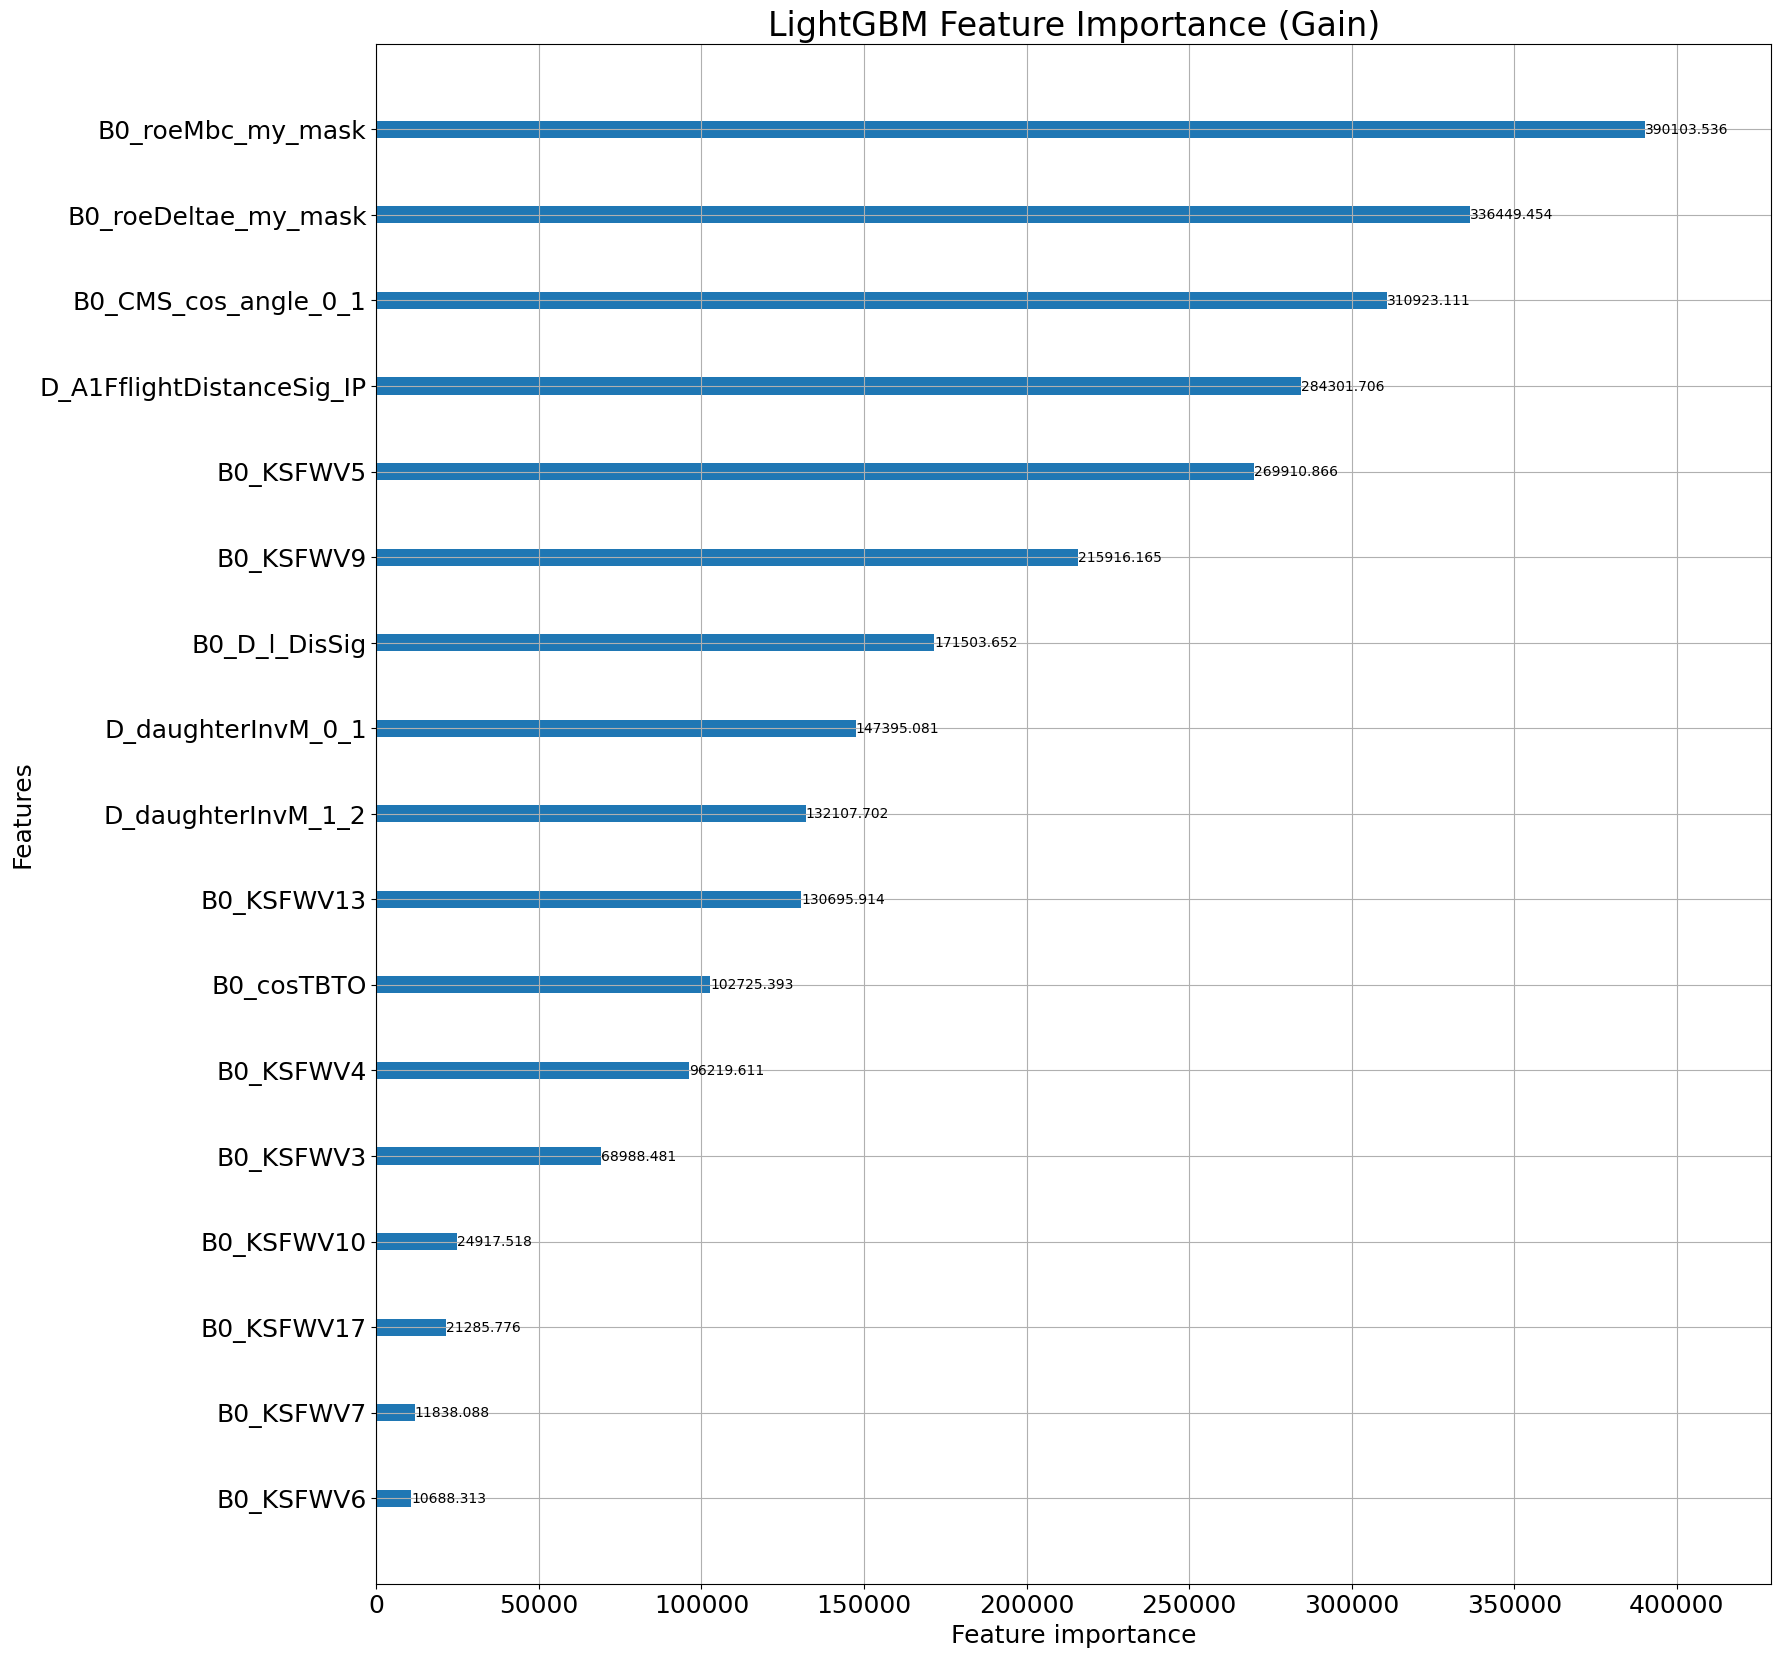

In [2]:
import lightgbm as lgb

predictor = lgb.Booster(model_file='/home/belle/zhangboy/inclusive_R_D/BDTs/LightGBM/lgbm_multiclass_v2.txt')

# Plotting top 10 features based on 'gain'
ax1=lgb.plot_importance(predictor, importance_type='gain', max_num_features=20, figsize=(18,20))
ax1.set_ylabel('Features', fontsize=18)
ax1.tick_params(axis='y', labelsize=18)
ax1.set_xlabel('Feature importance', fontsize=18)
ax1.tick_params(axis='x', labelsize=18)
ax1.set_title("LightGBM Feature Importance (Gain)", fontsize=24)

In [2]:
# 4S Data vs MC
# (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0) and 1.855<D_M<1.885

# Load data files
MC_4S_loose = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run2_deimos_BDT_e_2.root:MC_e_loose'],
                          library="np",
                          cut = cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_loose = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run2_deimos_BDT_e_2.root:Data_e_loose'],
                          library="np",
                          cut = cut,
                          filter_branch=lambda branch: branch.name in columns)

df_mc_4S_loose = pd.DataFrame(MC_4S_loose)
df_data_4S_loose = pd.DataFrame(data_4S_loose)

pi0_eff_table = '/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/pi0_eff50_corr.csv'
df_mc_4S_loose = util.apply_pi0_eff_correction(df_mc_4S_loose, pi0_eff_table)

          pi0_p  pi0_cosTheta
count  193637.0      193637.0
mean       -1.0          -1.0
std         0.0           0.0
min        -1.0          -1.0
25%        -1.0          -1.0
50%        -1.0          -1.0
75%        -1.0          -1.0
max        -1.0          -1.0


In [2]:
# # 4S Data vs MC
# Dst_veto_cut = '(DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0) and 1.855<D_M<1.885'

# # Load data files
# MC_4S_loose = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/e_channel/4S_run1_deimos_BDT1.root:MC_e_loose'],
#                           library="np",
#                           cut = cut,
#                           filter_branch=lambda branch: branch.name in columns)

# data_4S_loose = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/e_channel/4S_run1_deimos_BDT1.root:Data_e_loose'],
#                           library="np",
#                           cut = cut,
#                           filter_branch=lambda branch: branch.name in columns)

# df_mc_4S_loose = pd.DataFrame(MC_4S_loose)
# df_data_4S_loose = pd.DataFrame(data_4S_loose)

# df_mc_4S_loose = df_mc_4S_loose.rename(columns={"__experiment__": "experiment", '__run__': 'run','__event__': 'event', '__production__': 'production'})
# df_data_4S_loose = df_data_4S_loose.rename(columns={"__experiment__": "experiment", '__run__': 'run','__event__': 'event', '__production__': 'production'})

In [3]:
import sysvar
import warnings

e_eff_table = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/e_efficiency_MC16rd_run2_TwophotonEe.csv')
pi_e_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/pi_e_fake_MC16rd_run2.csv')
K_e_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/K_e_fake_MC16rd_run2.csv')

tables = {(11, 11): e_eff_table,
          (11, 211): pi_e_fake,
          (11, 321): K_e_fake}
thresholds = {11: ('electronIDNN', 0.9)}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sysvar.add_weights_to_dataframe('ell_BFbrems', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_loose,
                             systematic='custom_PID',
                             custom_tables=tables,
                             custom_thresholds=thresholds)

k_eff_table = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/k_efficiency_MC16rd_run2.csv')
pi_k_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/pi_k_fake_MC16rd_run2.csv')

tables = {(321, 321): k_eff_table,
          (321, 211): pi_k_fake,}
thresholds = {321: ('kaonIDNN', 0.9)}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sysvar.add_weights_to_dataframe('K', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_loose,
                             systematic='custom_PID',
                             custom_tables=tables,
                             custom_thresholds=thresholds)

pi_eff_table = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/pi_efficiency_MC16rd_run2.csv')
k_pi_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/k_pi_fake_MC16rd_run2.csv')

tables = {(211, 211): pi_eff_table,
          (211, 321): k_pi_fake,}
thresholds = {211: ('pionIDNN', 0.1)}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sysvar.add_weights_to_dataframe('pi1', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_loose,
                             systematic='custom_PID',
                             custom_tables=tables,
                             custom_thresholds=thresholds)
    sysvar.add_weights_to_dataframe('pi2', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_loose,
                             systematic='custom_PID',
                             custom_tables=tables,
                             custom_thresholds=thresholds)

Required variables: ['ell_BFbrems_cosTheta', 'ell_BFbrems_charge', 'ell_BFbrems_p', 'ell_BFbrems_PDG', 'ell_BFbrems_mcPDG']
Required variables: ['K_cosTheta', 'K_charge', 'K_p', 'K_PDG', 'K_mcPDG']
Required variables: ['pi1_cosTheta', 'pi1_charge', 'pi1_p', 'pi1_PDG', 'pi1_mcPDG']
Required variables: ['pi2_cosTheta', 'pi2_charge', 'pi2_p', 'pi2_PDG', 'pi2_mcPDG']


In [4]:
df_mc_4S_loose["total_PIDweight"] = df_mc_4S_loose[["ell_BFbrems_Weight", "K_Weight",'pi1_Weight','pi2_Weight']].product(axis = 1)
df_mc_4S_loose["total_weight"] = df_mc_4S_loose[["total_PIDweight", "pi0_eff_weight",]].product(axis = 1)

/tmp/ipykernel_1170451/3819086684.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_mc_4S_loose["total_PIDweight"] = df_mc_4S_loose[["ell_BFbrems_Weight", "K_Weight",'pi1_Weight','pi2_Weight']].product(axis = 1)
/tmp/ipykernel_1170451/3819086684.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_mc_4S_loose["total_weight"] = df_mc_4S_loose[["total_PIDweight", "pi0_eff_weight",]].product(axis = 1)


In [ ]:
# # Load the PID weights saved from systematic correction framework
# from sysvar import add_weights_to_dataframe

# add_weights_to_dataframe(
#     df = df_mc_4S_loose,
#     systematic= "eID_eff",
#     MC_production= "MC15rd",
#     prefix= "ell",
#     weightname ="eID_eff_weight",
#     #overwrite: False,
#     #Nvar: 0
# )

# add_weights_to_dataframe(
#     df = df_mc_4S_loose,
#     systematic= "eID_pi_fake",
#     MC_production= "MC15rd",
#     prefix= "ell",
#     weightname ="eID_pi_fake_weight",
#     #overwrite: False,
#     #Nvar: 0
# )

# add_weights_to_dataframe(
#     df = df_mc_4S_loose,
#     systematic= "eID_K_fake",
#     MC_production= "MC15rd",
#     prefix= "ell",
#     weightname ="eID_K_fake_weight",
#     #overwrite: False,
#     #Nvar: 0
# )

# # if multiple correction weights exist, combine them
# df_mc_4S_loose["total_PID_weight"] = df_mc_4S_loose[["ell_eID_eff_weight", "ell_eID_pi_fake_weight", "ell_eID_K_fake_weight",]].product(axis = 1)

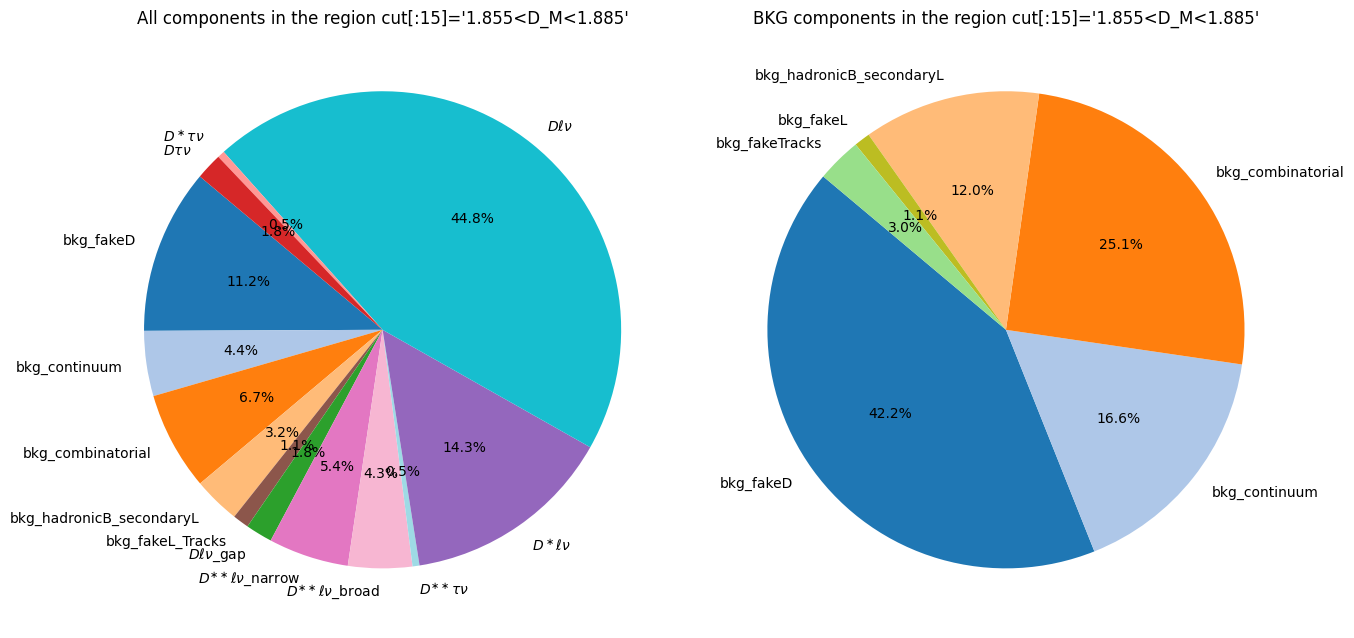

In [48]:
mpl_mc.plot_pie(cut=f'1.855<D_M<1.885 and {lgb_tight} and (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0) and fakeD_prob<0.06')

In [5]:
# df_mc_4S_loose['ell_BFbrems_mcPDG'] = df_mc_4S_loose['ell_mcPDG']
samples=util.classify_mc_dict(df_mc_4S_loose, 'e', template=False)

mpl_mc=util.mpl(samples)
mpl=util.mpl(samples, df_data_4S_loose)

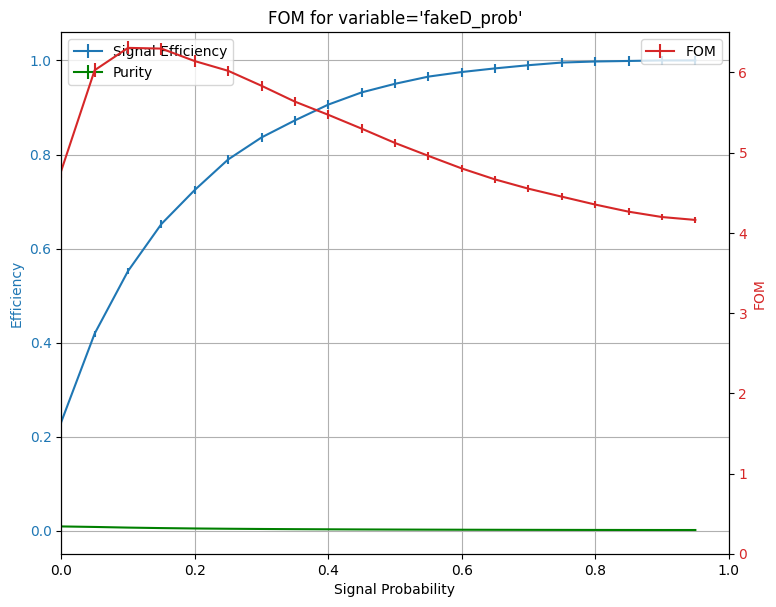

In [27]:
# lightgbm
tests = np.linspace(0,1,21)
mpl.plot_FOM(sigModes=[r'$D\tau\nu$'],bkgModes=['bkg_fakeTracks','bkg_continuum','bkg_combinatorial',
                                                'bkg_fakeD','bkg_fakeL','bkg_hadronicB_secondaryL'],
            variable='fakeD_prob', bins=tests, cut='sig_prob>0.2',reverse_selection=True)

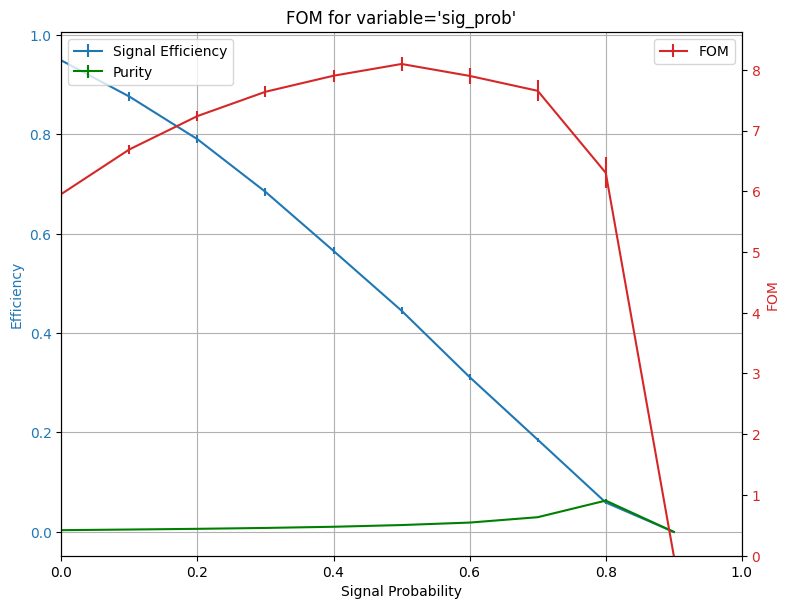

In [26]:
# lgbm
tests = np.linspace(0,1,11)
mpl.plot_FOM(sigModes=[r'$D\tau\nu$'],bkgModes=['bkg_fakeTracks','bkg_continuum','bkg_combinatorial',
                                                'bkg_fakeD','bkg_fakeL','bkg_hadronicB_secondaryL'],
            variable='sig_prob', cut='fakeD_prob<0.15 and continuum_prob<0.4 and combinatorial_prob<0.6', bins=tests)

# sig_prob>0.6 and fakeD_prob < 0.2, continumm_prob, comb_prob

In [35]:
# new
for name, df in samples.items():
    print(name, len(df))

bkg_fakeD 1463972
bkg_fakeL 3857
bkg_fakeTracks 35366
bkg_continuum 52944
bkg_combinatorial 87409
bkg_hadronicB_secondaryL 35130
bkg_other_TDTl 0
$D\tau\nu$ 9081
$D^\ast\tau\nu$ 5915
$D\ell\nu$ 183564
$D^\ast\ell\nu$ 138376
$D^{\ast\ast}\tau\nu$ 4242
$D^{\ast\ast}\ell\nu$_narrow 42837
$D^{\ast\ast}\ell\nu$_broad 29300
$D\ell\nu$_gap 17837
bkg_other_signal 0


In [5]:
for name, df in samples.items():
    print(name, len(df))

bkg_fakeD 560514
bkg_TDFl 4336
bkg_fakeTracks 11957
bkg_continuum 45861
bkg_combinatorial 59597
bkg_singleBbkg 34861
bkg_other_TDTl 0
$D\tau\nu$ 14039
$D^\ast\tau\nu$ 8370
$D\ell\nu$ 274795
$D^\ast\ell\nu$ 188559
$D^{\ast\ast}\tau\nu$ 5323
$D^{\ast\ast}\ell\nu$_narrow 56150
$D^{\ast\ast}\ell\nu$_broad 40808
$D\ell\nu$_gap_pi 11076
$D\ell\nu$_gap_eta 9280
bkg_other_signal 0


# Control regions
## 0. D_M sidebands

cut= (D_M<1.82 or 1.9<D_M) and sig_prob>0.5 and fakeD_prob<0.15 and continuum_prob<0.4 and combinatorial_prob<0.6


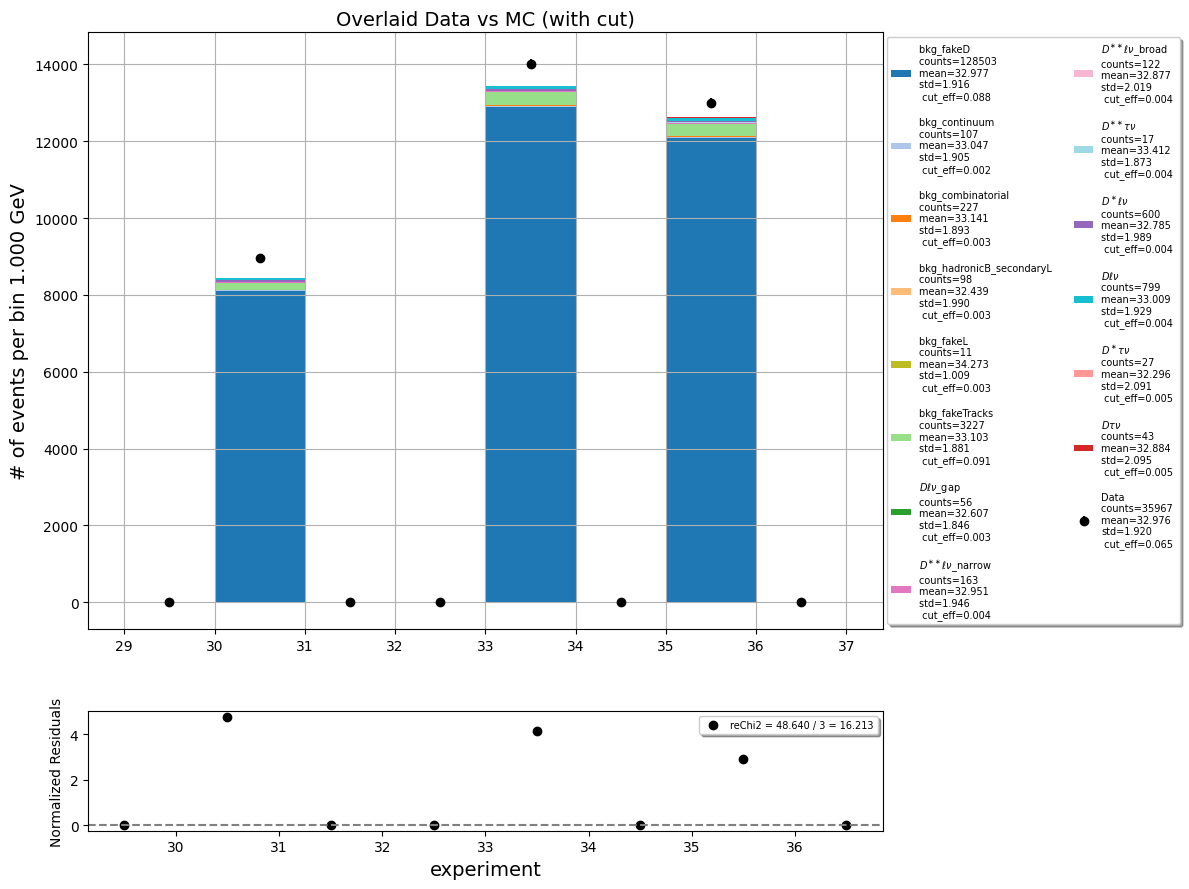

In [68]:
# new sample, new plot
b1 = np.array([29,30,31,32,33,34,35,36,37])
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='experiment',bins=b1,cut=f'(D_M<1.82 or 1.9<D_M) and {lgb_tight}',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= (D_M<1.82 or 1.9<D_M) and sig_prob>0.5 and fakeD_prob<0.15 and continuum_prob<0.4 and combinatorial_prob<0.6


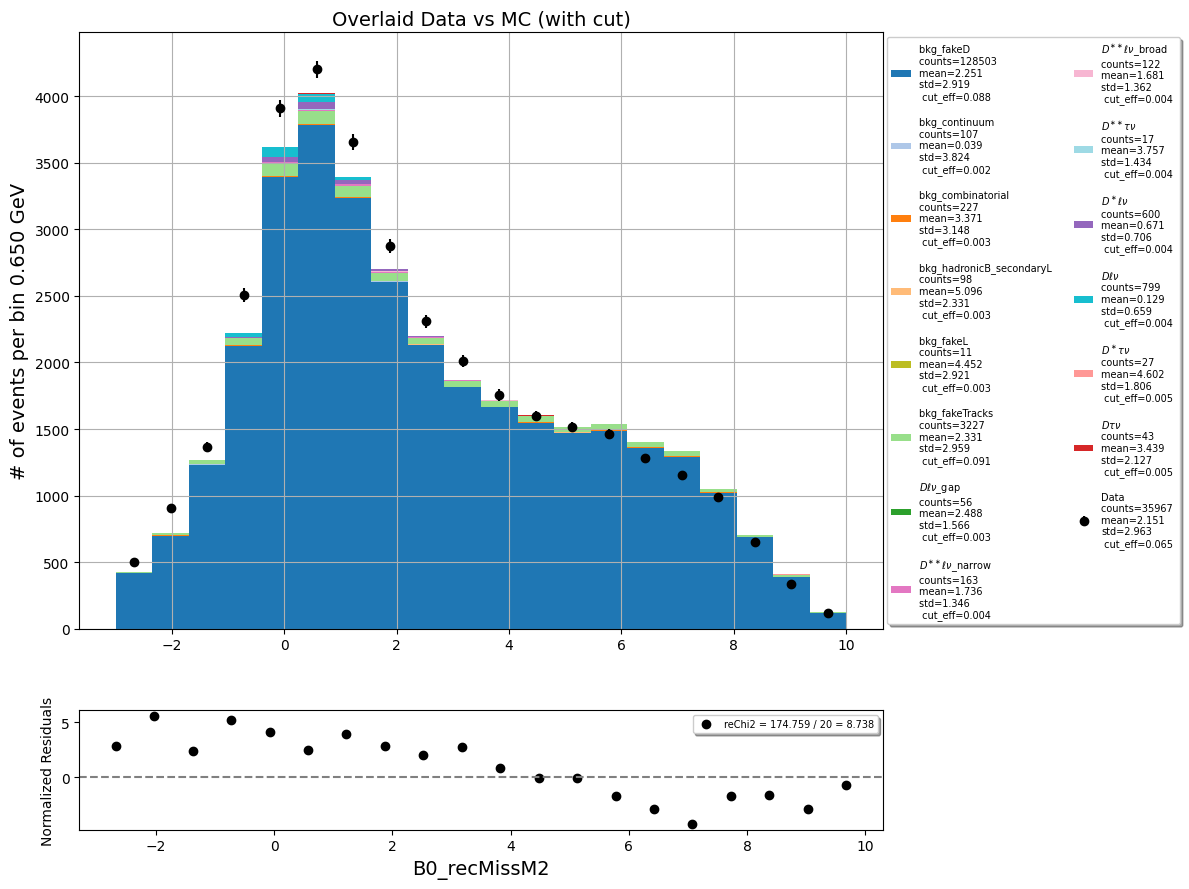

In [69]:
# new sample, new plot, exp<18
b1 = np.linspace(-3,10,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'(D_M<1.82 or 1.9<D_M) and {lgb_tight}',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= (D_M<1.82 or 1.9<D_M) and sig_prob>0.5 and fakeD_prob<0.15 and continuum_prob<0.4 and combinatorial_prob<0.6


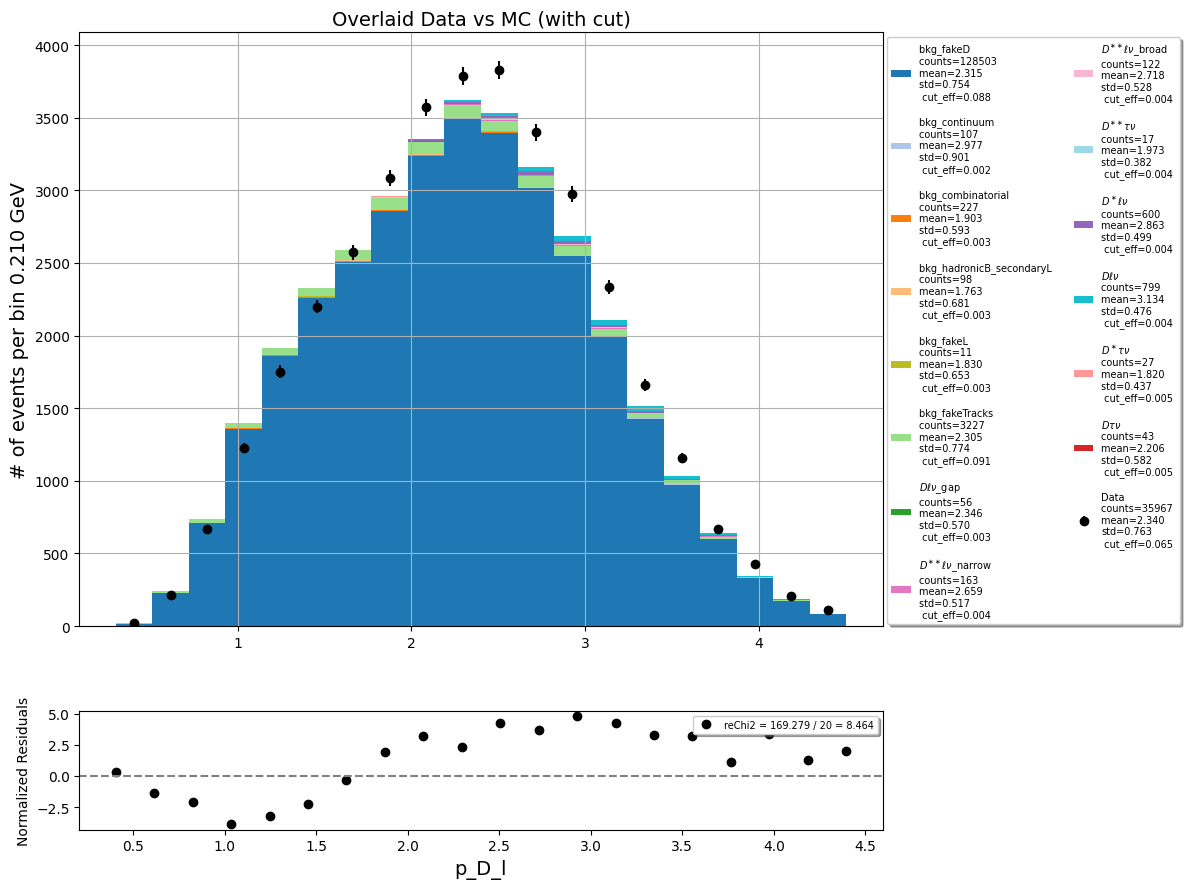

In [70]:
# new sample, new plot, exp<18
b1 = np.linspace(0.3,4.5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut=f'(D_M<1.82 or 1.9<D_M) and {lgb_tight}',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

## 1. q^2 < 3

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885


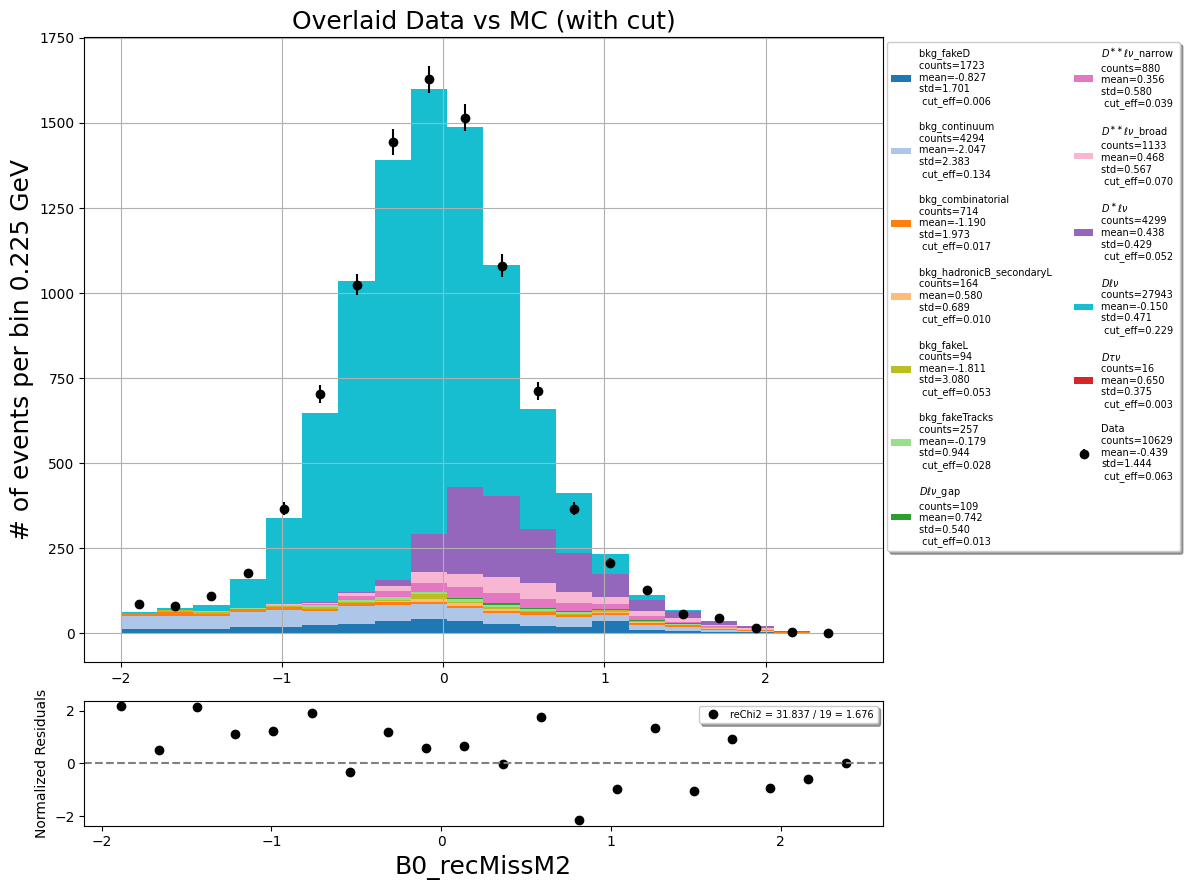

In [7]:
# new sample, new plot, new BDT
b1 = np.linspace(-2,2.5,21)
weights={'all_mc':0.25 * 1.029,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights, text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885 and -1.5<B0_recMissM2<-0.2


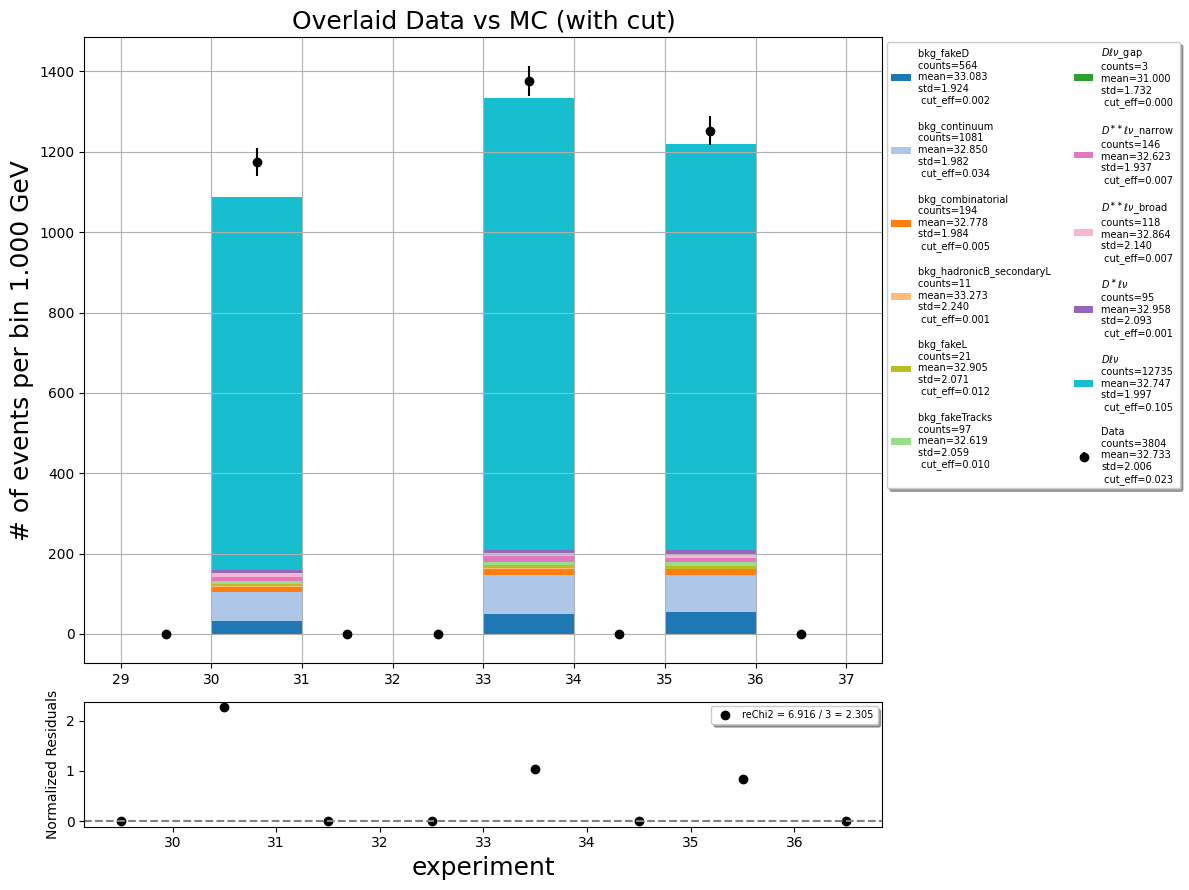

In [6]:
# new sample, new plot
b1 = np.array([29,30,31,32,33,34,35,36,37])
weights={'all_mc':0.25 * 1.029,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='experiment',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and 1.855<D_M<1.885 and -1.5<B0_recMissM2<-0.2',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights, text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

In [77]:
n_expected = np.array([2374566, 726593, 453889, 472552, 3611657, 165268, 1413081, 3776830, 2416480]) * 0.25 * 0.0938
eff_mc = mc_hist_all / n_expected
eff_data = data_hist_all / n_expected

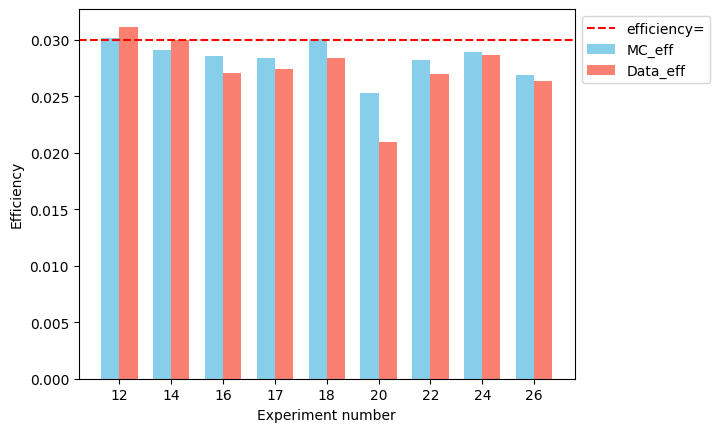

In [101]:
labels = ['12', '14', '16', '17', '18', '20', '22', '24', '26']

x = np.arange(len(labels))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots()
# Plot each group with a different color and shifted position
rects1 = ax.bar(x - width/2, [eff.n for eff in eff_mc], width, label='MC_eff', color='skyblue')
rects2 = ax.bar(x + width/2, [eff.n for eff in eff_data], width, label='Data_eff', color='salmon')
plt.axhline(y=0.03, color='r', linestyle='--', label='efficiency=')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Experiment number')
ax.set_ylabel('Efficiency')
ax.legend(bbox_to_anchor=(1,1))
plt.show()

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and experiment==30 and 1.855<D_M<1.885 and -1.5<B0_recMissM2<-0.2


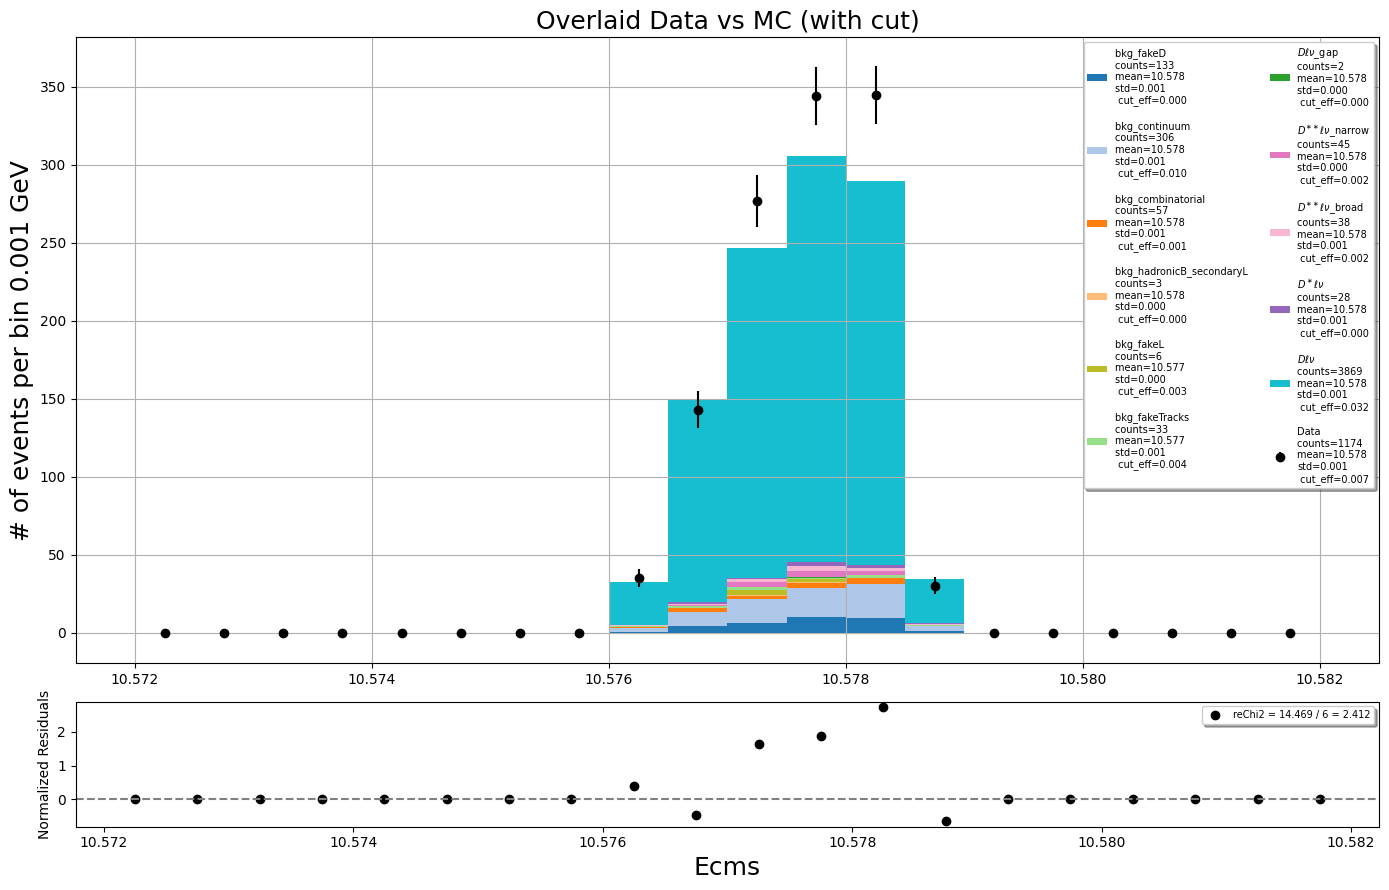

In [20]:
# new sample, new plot
b1 = np.linspace(10.572,10.582,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='Ecms',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and experiment==30 and 1.855<D_M<1.885 and -1.5<B0_recMissM2<-0.2',mask=[],
    figsize=(14,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and -1.5<B0_recMissM2<-0.2


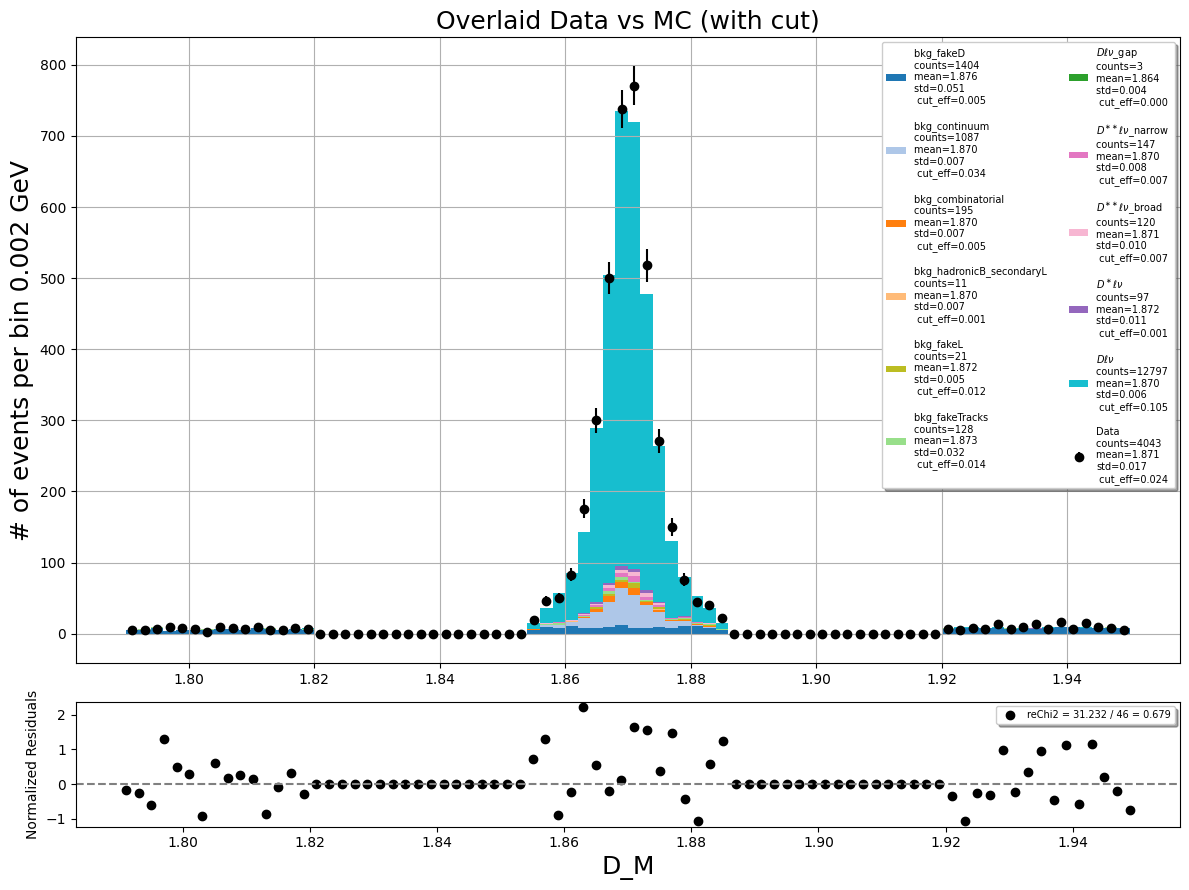

In [7]:
b1 = np.linspace(1.79,1.95,81)
weights={'all_mc':0.25 * 1.029,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='D_M',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and -1.5<B0_recMissM2<-0.2',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

In [ ]:
b1 = np.linspace(0,3000,31)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='run',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and experiment==30',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=False, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885 and -1.5<B0_recMissM2<-0.2


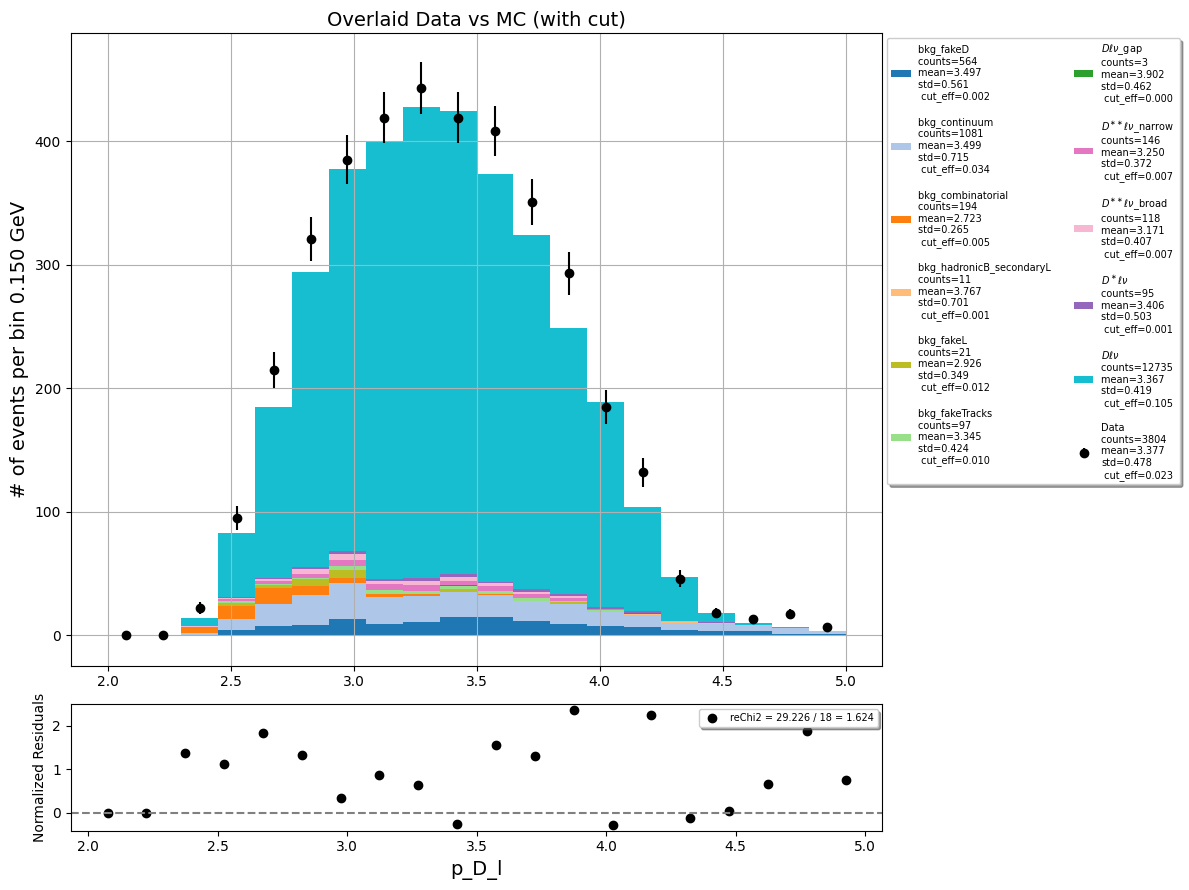

In [12]:
# new sample, new plot, exp<18
b1 = np.linspace(2,5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and 1.855<D_M<1.885 and -1.5<B0_recMissM2<-0.2',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885 and -1.5<B0_recMissM2<-0.2


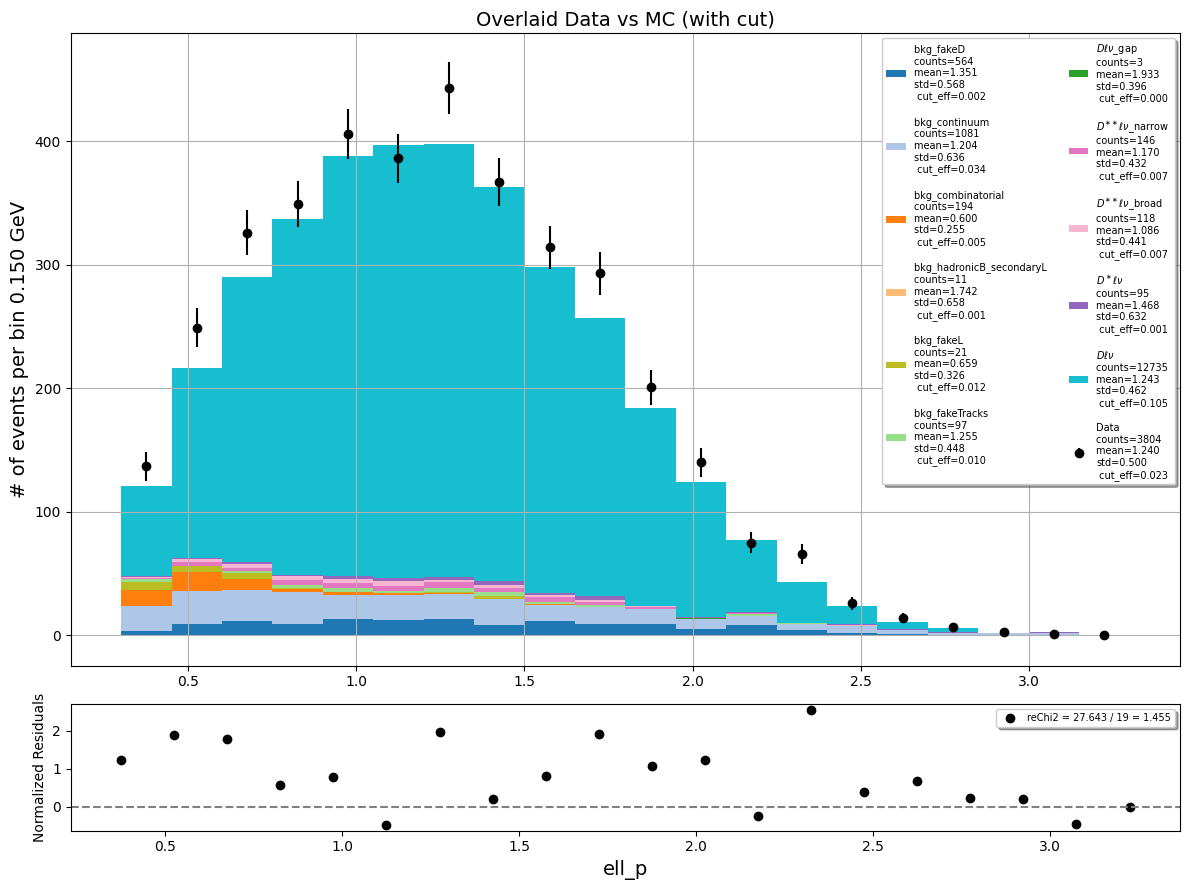

In [13]:
# new sample, new plot, exp<18
b1 = np.linspace(0.3,3.3,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='ell_p',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and 1.855<D_M<1.885 and -1.5<B0_recMissM2<-0.2',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885 and sig_prob>0.5 and fakeD_prob<0.15 and continuum_prob<0.4 and combinatorial_prob<0.6


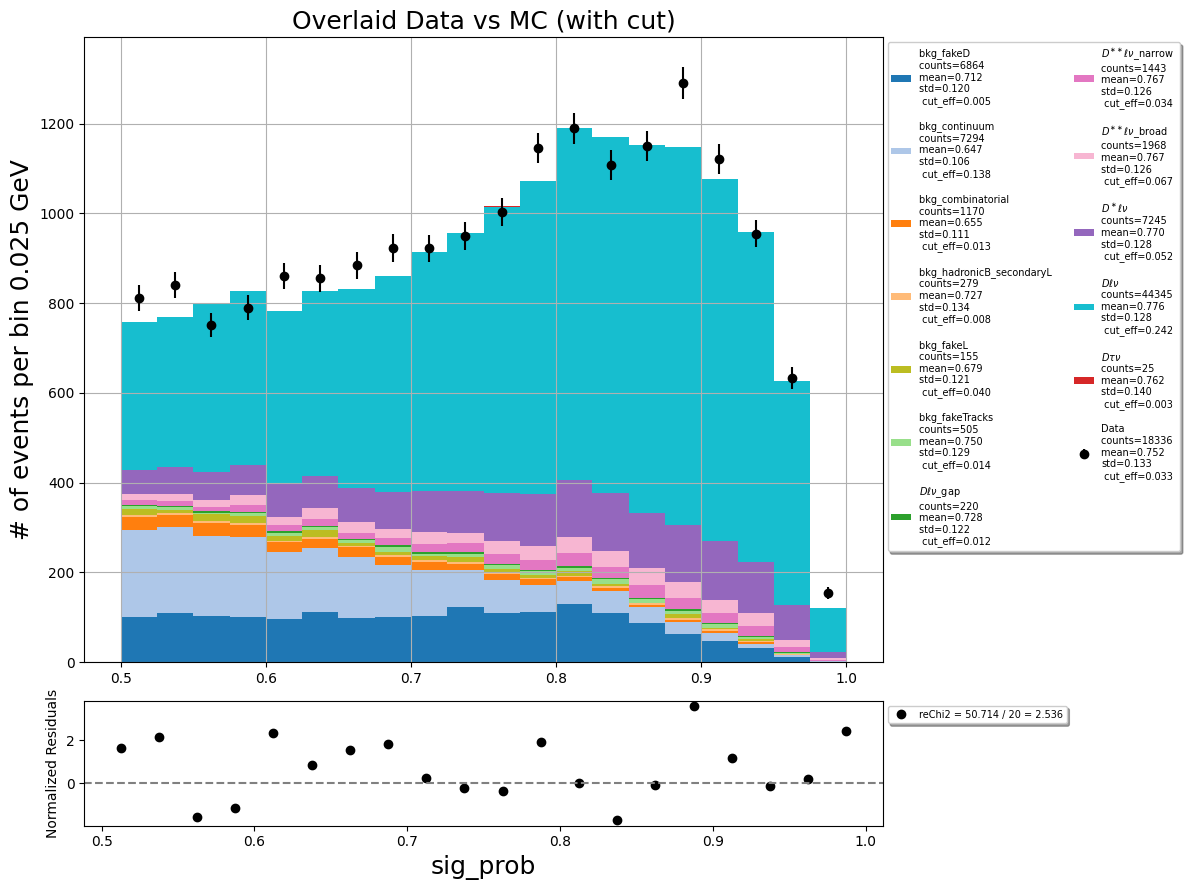

In [102]:
# new sample, new plot
b1 = np.linspace(0.5,1,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='sig_prob',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885 and {lgb_tight} and -1.5<B0_recMissM2<-0.2',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights, text_fs=18,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

### 1.1 Fit

In [8]:
# Create the bin edges
p_D_l_bins = np.concatenate(([0.4, 0.6, 0.8], 
                             np.linspace(1,3,41), 
                             [3.1, 3.2, 3.3, 3.4, 3.6, 3.8, 4, 4.2, 4.4, 4.6, 4.8]))

# Create the bin edges
MM2_bins = np.concatenate((np.linspace(-2.5,2.5,11), np.linspace(2.8,10,31) ) )

MM2_bins_sb = np.linspace(-2.5,10,21)
p_D_l_bins_sb = np.linspace(0.4,4.8,21)

# create templates
df_mc_4S_q2SB = df_mc_4S_loose.query(f'B0_recQ2BhSimple<3 and {lgb_tight}')
df_data_4S_q2SB = df_data_4S_loose.query(f'B0_recQ2BhSimple<3 and {lgb_tight}')
samples_q2SB=util.classify_mc_dict(df_mc_4S_q2SB, 'e', template=False)

In [9]:
## MC16rd e
temp_data_e_sr,temp_data_e_sb,temp_data_e_sr_merged, temp_data_e_sb_merged = util.create_templates_new(
                    samples=samples_q2SB,
                    variables=['B0_recMissM2','p_D_l'], bin_threshold=10,merge_threshold=5,
                    bins_sr=[MM2_bins, p_D_l_bins], scale_lumi=1,
                    bins_sb=[MM2_bins_sb, p_D_l_bins_sb],
                    use_real_data_instead_of_asimov=True, real_data=df_data_4S_q2SB,
                    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight',
                    sample_to_exclude=['bkg_other_TDTl','bkg_other_signal',
                                      r'$D\ell\nu$_gap',
                                       # 'bkg_fakeD', 
                                       # 'bkg_continuum',
                #                       r'$D^{\ast\ast}\ell\nu$_broad',
                #                       r'$D^{\ast\ast}\ell\nu$_narrow',
                #                       r'$D\ell\nu$',
                #                       r'$D^\ast\ell\nu$',
                #                       r'$D\tau\nu$', 
                #                       r'$D^\ast\tau\nu$', 
                #                       r'$D^{\ast\ast}\tau\nu$',
                                      #  'bkg_fakeTracks',
                                      # 'bkg_TDFl','bkg_singleBbkg',
                                      # 'bkg_combinatorial',
                                      ],
                    sample_weights={r'$D\ell\nu$_gap':              0,  
                                    r'$D^{\ast\ast}\ell\nu$_broad': 0.25 * 1.435 * 1.029, # 11540 events from 1/ab
                                    r'$D^{\ast\ast}\ell\nu$_narrow':0.25 * 1.029,
                                    r'$D\ell\nu$':                  0.25 * 1.029,
                                    r'$D^\ast\ell\nu$':             0.25 * 1.029,
                                    r'$D\tau\nu$':                  0.25 * 1.029 , 
                                    r'$D^\ast\tau\nu$':             0.25 * 1.029 , 
                                    r'$D^{\ast\ast}\tau\nu$':       0.25 * 0.33 * 1.029,
                                    'bkg_fakeD':                    0.25 * 1.029, # here for signal region
                                    'bkg_TDFl':                     0.25 * 1.029,
                                    'bkg_continuum':                0.25 * 1.029,
                                    'bkg_combinatorial':            0.25 * 1.029,
                                    'bkg_singleBbkg':               0.25 * 1.029,
                                    'bkg_fakeTracks':               0.25 * 1.029,
                                    })

Creating templates for the signal region
Creating templates for D_M sidebands channel
creating new templates with merged bins in the signal region, original template length = 128, new template (merge small bins) length = 128
creating new templates with merged bins in the D mass sidebands, original template length = 26, new template (merge small bins) length = 26


In [10]:
import pyhf
import cabinetry
cabinetry.set_logging()
spec_e_sb = util.create_workspace(temp_data_channels=[temp_data_e_sr, temp_data_e_sb], mc_uncer=True,fakeD_uncer=True)
spec_e_sb['measurements'] = [{"name": "q2_sideband", "config": {"poi": "$D\\ell\\nu$_norm", "parameters": []}}]
model_e_sb, data_e_sb = cabinetry.model_utils.model_and_data(spec_e_sb)

INFO - pyhf.workspace - Validating spec against schema: workspace.json
INFO - pyhf.pdf - Validating spec against schema: model.json
INFO - pyhf.pdf - adding modifier $D\ell\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D\tau\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D^\ast\ell\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D^{\ast\ast}\ell\nu$ + gap_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier bkg_fakeD_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier bkg_continuum_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier mcStat_ch0 (128 new nuisance parameters)
INFO - pyhf.pdf - adding modifier mcStat_ch1 (26 new nuisance parameters)


In [11]:
fit_results = cabinetry.fit.fit(model=model_e_sb, data=data_e_sb,goodness_of_fit=True,
                                fix_pars=[False, True]
                               )

INFO - cabinetry.fit - performing maximum likelihood fit
INFO - cabinetry.fit - Migrad status:
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 551.8                      │             Nfcn = 30249             │
│ EDM = 0.000148 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴─────────────────────────────────

5

In [14]:
fitter = util.fit_Dmass(x_edges=b1, hist=data_hist_all, poly_only=True)
m_ml, c_ml, result_ml = fitter.fit_gauss_poly_ML(deg=1)
m_ml

initial parameters= [ 1.1850e+02  1.8700e+00  2.0000e-02  5.9268e+04  1.8180e+02 -9.3100e+01]


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 27.27 (χ²/ndof = 1.0)      │              Nfcn = 142              │
│ EDM = 3.82e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x0   │    0.0    │    1.2    │            │            │    0    │         │  yes  │
│ 1 │ x1   │   1.870   │   0.019   │            │            │    0    │         │  yes  │
│ 2 │ x2   │  20.0e-3  │  0.2e-3   │            │            │    0    │         │  yes  │
│ 3 │ x3   │  19.80e3  │  0.23e3   │            │            │         │         │       │
│ 4 │ x4   │   0.1e3   │   0.7e3   │            │            │         │         │       │
│ 5 │ x5   │  -0.06e3  │  0.32e3   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────────────────────────────────────────┐
│    │       x0       x1       x2       x3       x4       x5 │
├────┼───────────────────────────────────────────────────────┤
│ x0 │        0        0        0        0        0        0 │
│ x1 │        0        0        0        0        0        0 │
│ x2 │        0        0        0        0        0        0 │
│ x3 │        0        0        0 5.46e+04        0        0 │
│ x4 │        0        0        0        0 4.63e+05  -0.22e6 │
│ x5 │        0        0        0        0  -0.22e6 1.05e+05 │
└────┴───────────────────────────────────────────────────────┘

In [15]:
yields_left = fitter.poly_integral(xrange=[1.79,1.82],result=result_ml)
yields_sig = fitter.poly_integral(xrange=[1.855,1.885],result=result_ml)
yields_right = fitter.poly_integral(xrange=[1.92,1.95],result=result_ml)

Yields from 1.79 to 1.82 = 3540.042 ± 61.021
Yields from 1.855 to 1.885 = 3713.238 ± 43.813
Yields from 1.92 to 1.95 = 3886.433 ± 62.279


In [17]:
a = len(df_data_4S_loose.query('1.79<D_M<1.82 and B0_recQ2BhSimple<3'))
b = len(df_data_4S_loose.query('1.92<D_M<1.95 and B0_recQ2BhSimple<3'))
print('data', a,b)

data 3532 3881


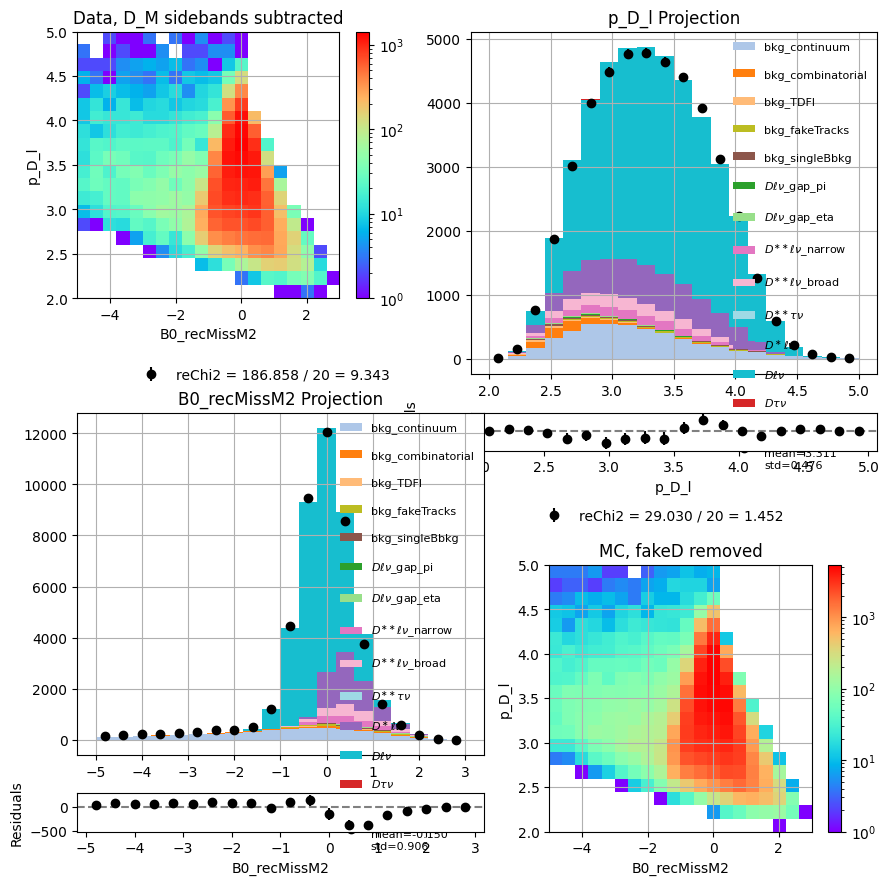

In [21]:
# e channel, lgb_loose
b_mm2 = np.linspace(-5,3,21)
b_pDl = np.linspace(2,5,21)
scale2 = {'data left sideband': 1550/1466/2,
         'data right sideband': 1550/1635/2,
         'data signal region': 1,
         'all_mc': 0.25}

par_dict={'var_list':['B0_recMissM2','p_D_l'],
          'bin_list': [b_mm2, b_pDl],
          'cut': 'B0_recQ2BhSimple<3', #'B0_roeMbc_my_mask>5.1 and -4<B0_roeDeltae_my_mask<1',
          'weights': scale2,
          'correction': False,
          'mask': ['bkg_fakeD']}
indices_threshold, temp_data = mpl.plot_data_subtracted_and_mc(**par_dict)

### 2. D* veto

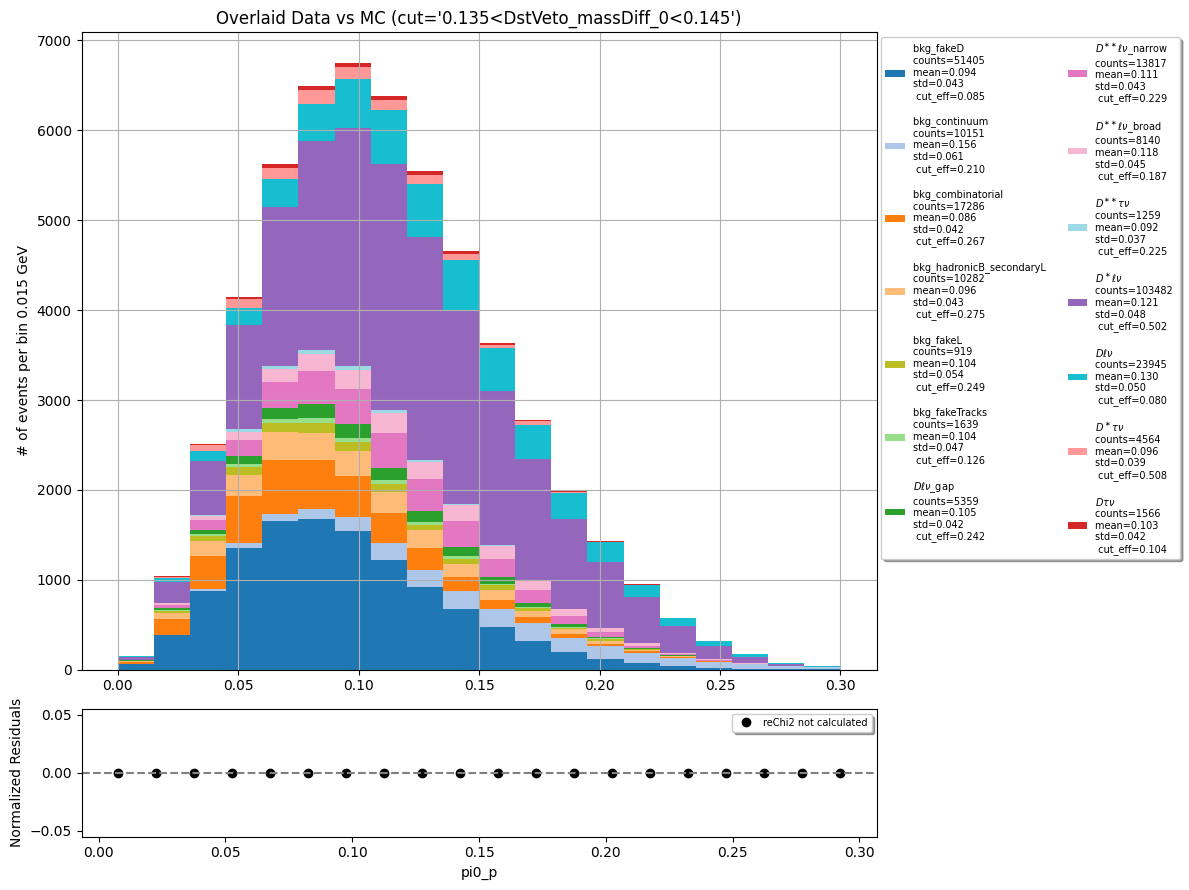

In [48]:
# e
b1 = np.linspace(0,0.3,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.9, r'$D^{\ast\ast}\ell\nu$_narrow':0.25*0.7,r'$D^{\ast\ast}\ell\nu$_broad':0.25*0.7,
        # 'bkg_singleBbkg':0.25*0.5, 'bkg_combinatorial':0.25*0.5}
data_hist_all, mc_hist_all = mpl_mc.plot_data_mc_stacked(
    variable='pi0_p',bins=b1,cut='0.135<DstVeto_massDiff_0<0.145',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')

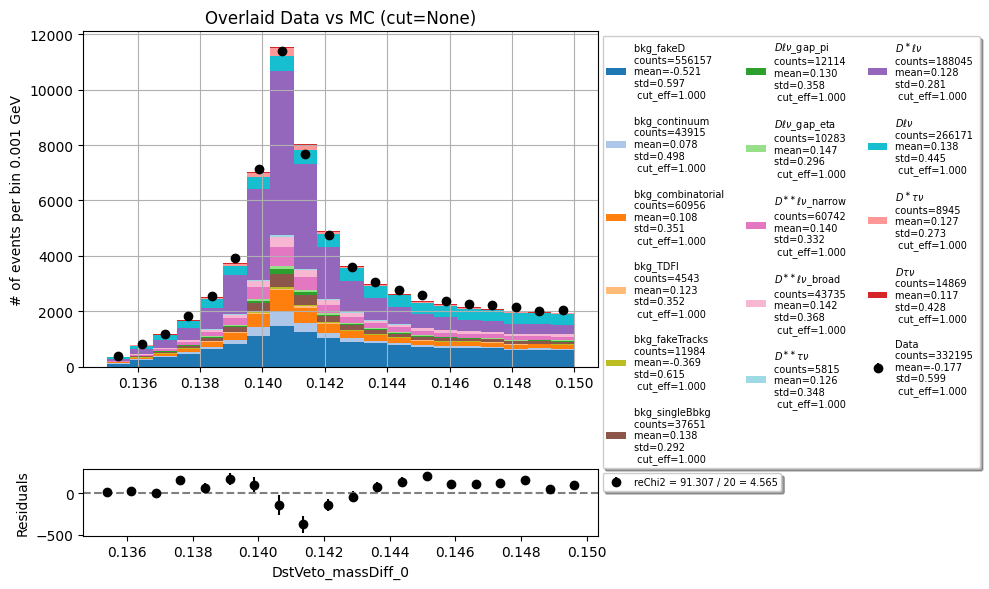

In [51]:
# e channel
b1 = np.linspace(0.135,0.15,21)
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='DstVeto_massDiff_0',bins=b1,cut=None,
    correction=False,mask=[],figsize=(10,6),ratio=False,
    weights={'all_mc':0.22},legend_nc=3, legend_fs=7)

cut= sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 0<B0_recMissM2<3 and 1.855<D_M<1.885 and 0.135<DstVeto_massDiff_0<0.145


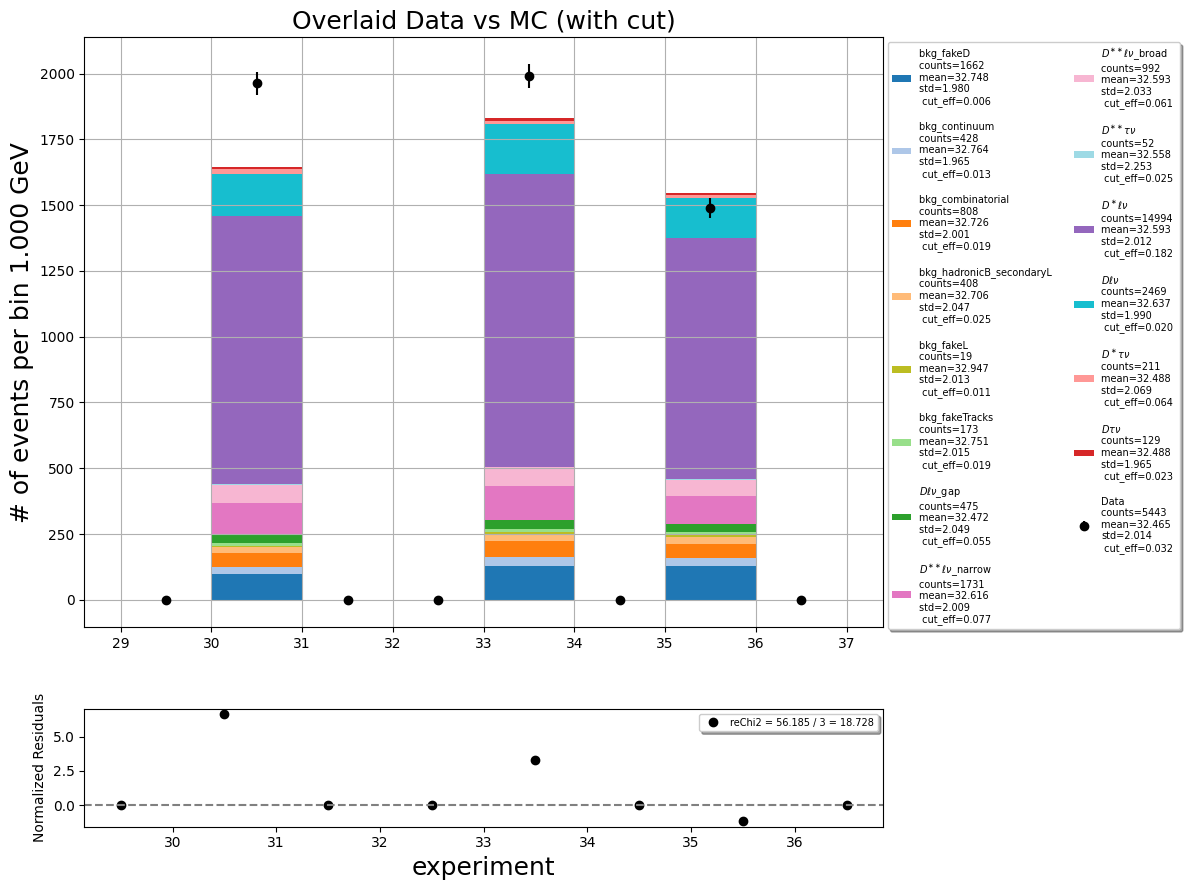

In [14]:
# new sample, new plot, new BDT
b1 = np.array([29,30,31,32,33,34,35,36,37])
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='experiment',bins=b1,cut=f'{lgb_tight} and 0<B0_recMissM2<3 and 1.855<D_M<1.885 and 0.135<DstVeto_massDiff_0<0.145',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights, text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')

cut= 0.135<DstVeto_massDiff_0<0.145 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885


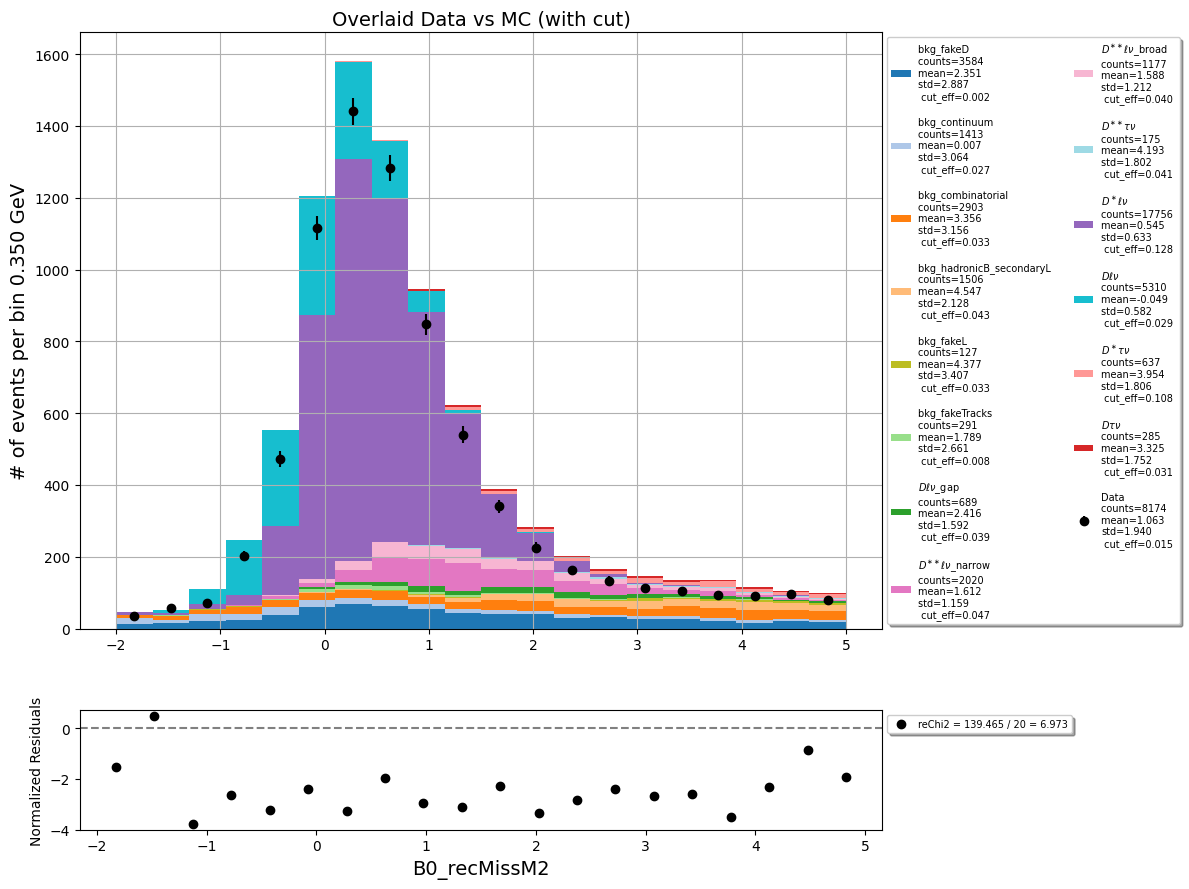

In [18]:
# exp<18
b1 = np.linspace(-2,5,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.9, r'$D^{\ast\ast}\ell\nu$_narrow':0.25*0.7,r'$D^{\ast\ast}\ell\nu$_broad':0.25*0.7,
        # 'bkg_singleBbkg':0.25*0.5, 'bkg_combinatorial':0.25*0.5}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'0.135<DstVeto_massDiff_0<0.145 and {lgb_tight} and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= 0.135<DstVeto_massDiff_0<0.145 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885


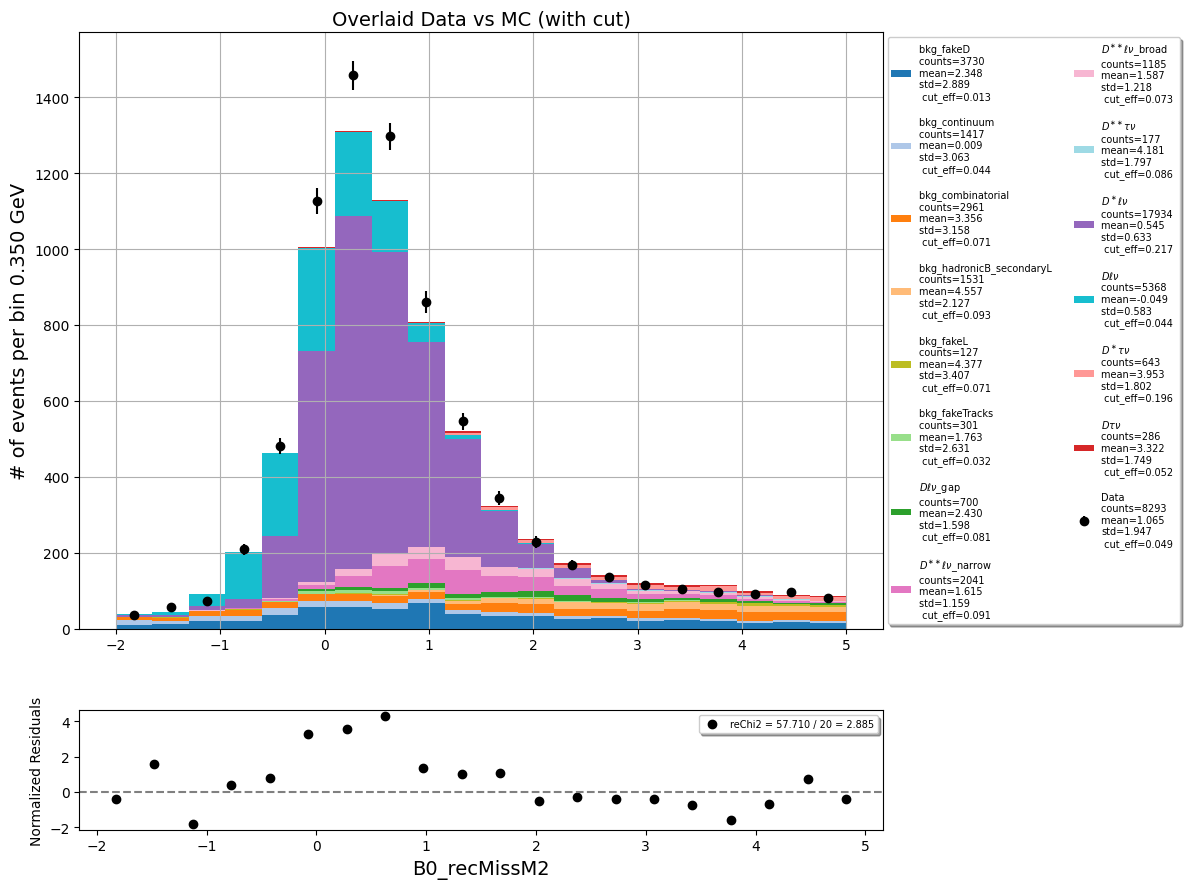

In [15]:
# exp<18
b1 = np.linspace(-2,5,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.9, r'$D^{\ast\ast}\ell\nu$_narrow':0.25*0.7,r'$D^{\ast\ast}\ell\nu$_broad':0.25*0.7,
        # 'bkg_singleBbkg':0.25*0.5, 'bkg_combinatorial':0.25*0.5}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'0.135<DstVeto_massDiff_0<0.145 and {lgb_tight} and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')

cut= 0.135<DstVeto_massDiff_0<0.145 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6


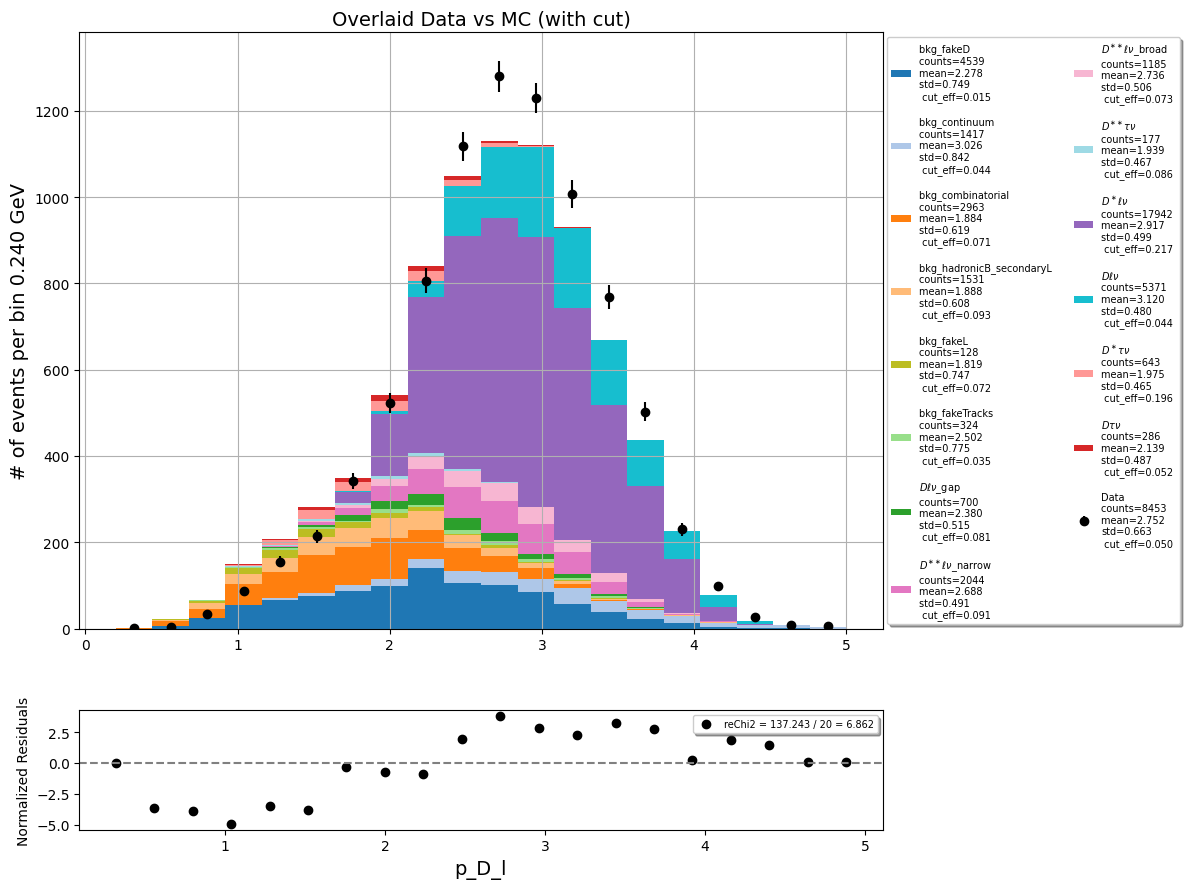

In [16]:
# exp<18
b1 = np.linspace(0.2,5,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.9, r'$D^{\ast\ast}\ell\nu$_narrow':0.25*0.7,r'$D^{\ast\ast}\ell\nu$_broad':0.25*0.7,
        # 'bkg_singleBbkg':0.25*0.5, 'bkg_combinatorial':0.25*0.5}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut=f'0.135<DstVeto_massDiff_0<0.145 and {lgb_tight}',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')

cut= sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 0<B0_recMissM2<3 and 0.135<DstVeto_massDiff_0<0.145


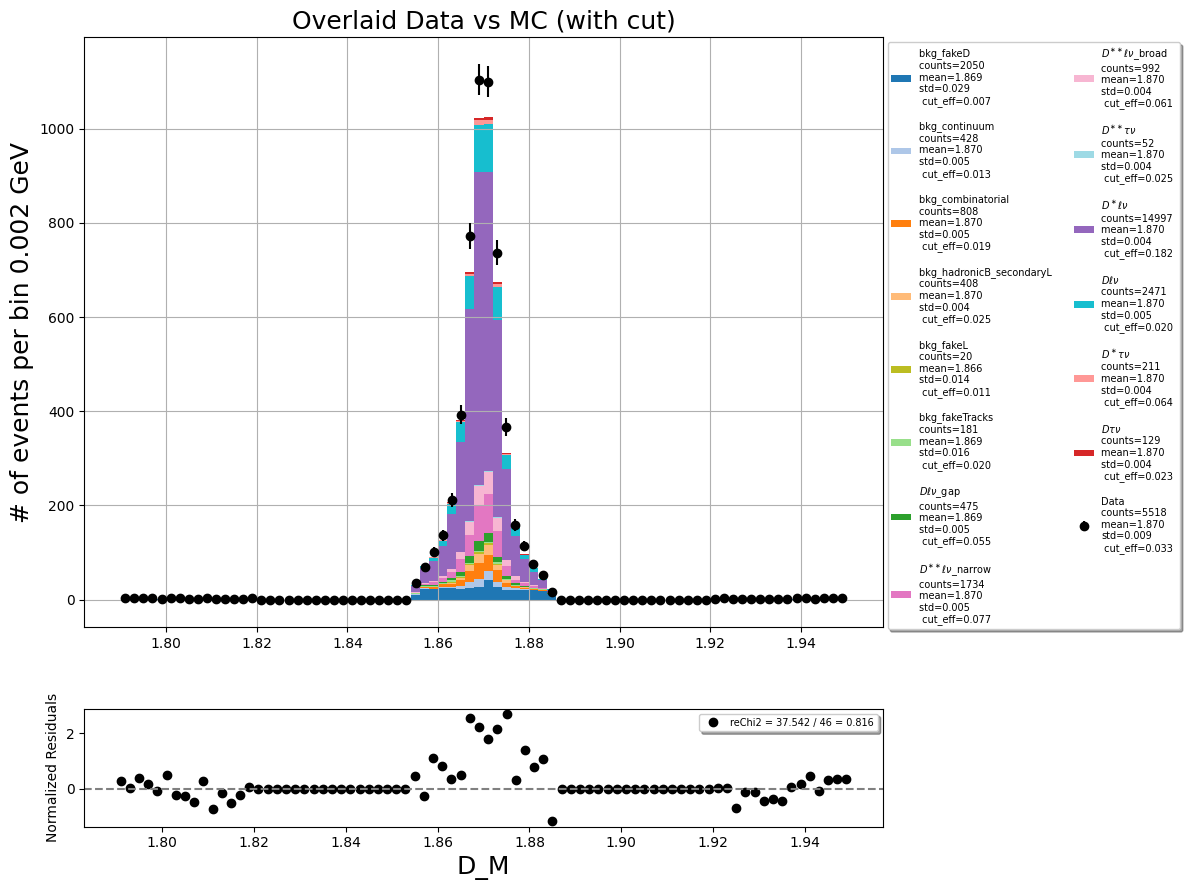

In [17]:
b1 = np.linspace(1.79,1.95,81)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='D_M',bins=b1,cut=f'{lgb_tight} and 0<B0_recMissM2<3 and 0.135<DstVeto_massDiff_0<0.145',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')